# TF-IDF formula diagnosis and EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

pd.set_option("display.width", 120)

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
feat = [c for c in train.columns if c != "y"]
full = pd.concat([train[feat], test[feat]], ignore_index=True)
N = len(full)

## TF-IDF formula diagnosis

In [3]:
X = full[feat]
nz = X > 0
n_j = nz.sum(axis=0)
m_i = nz.sum(axis=1)

print(f"N = {N}")
n_j

N = 4934


salt          3642
sugar         1368
water         2501
cereals        395
oil           2500
flour         1983
fruits        1286
milk          1139
seeds         1330
onion         1149
garlic        1345
chocolate      485
yeast          504
egg           1998
vinegar        303
tomato         875
cream          616
rice           339
corn           336
cheese        1524
butter        1545
red.meat       710
white.meat     570
potato         549
honey          352
paprika        265
mustard        150
turmeric        49
ginger         168
parsley        538
wine           475
chili          222
mushrooms      126
bread          518
pasta          146
fish           185
seafood        184
veggies        825
legumes        860
pepper        2327
dtype: int64

In [4]:
# recover TF under the stated formula IDF_j = log(N/n_j)
idf_stated = np.log(N / n_j)
TF_stated = X.div(idf_stated, axis=1).where(nz, 0.0)
row_sum_stated = TF_stated.sum(axis=1)
row_sum_stated.describe()

count    4934.000000
mean        1.417528
std         0.156057
min         1.008284
25%         1.321316
50%         1.416663
75%         1.503162
max         2.212133
dtype: float64

In [5]:
# is x_ij * m_i constant within each column j?
C = X.mul(m_i, axis=0).where(nz)
pd.DataFrame({"C_mean": C.mean(), "C_std": C.std()})

,C_mean,C_std
salt,0.856435,5.599750e-14
sugar,1.527517,2.565717e-15
water,1.089508,3.179589e-14
cereals,2.602033,8.555986e-15
oil,1.089773,3.358522e-14
flour,1.249371,3.668489e-14
fruits,1.576233,1.864379e-14
milk,1.673702,2.255168e-14
seeds,1.549640,3.469645e-14
onion,1.666606,4.594940e-14


In [6]:
# compare that per-column constant to candidate IDF formulas
idf_plain = np.log(N / n_j)
idf_log1p = np.log1p(N / n_j)
pd.DataFrame({
    "C_j": C.mean(),
    "log(N/n_j)": idf_plain,
    "log(1+N/n_j)": idf_log1p,
})

,C_j,log(N/n_j),log(1+N/n_j)
salt,0.856435,0.303617,0.856435
sugar,1.527517,1.282800,1.527517
water,1.089508,0.679459,1.089508
cereals,2.602033,2.525020,2.602033
oil,1.089773,0.679859,1.089773
flour,1.249371,0.911539,1.249371
fruits,1.576233,1.344613,1.576233
milk,1.673702,1.465999,1.673702
seeds,1.549640,1.310971,1.549640
onion,1.666606,1.457258,1.666606


In [7]:
# row sums under the candidate formula IDF_j = log(1 + N/n_j)
TF_log1p = X.div(idf_log1p, axis=1).where(nz, 0.0)
row_sum_log1p = TF_log1p.sum(axis=1)
row_sum_log1p.describe()

count    4.934000e+03
mean     1.000000e+00
std      6.255974e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

In [8]:
# elementwise residual against x_ij = (1/m_i) * log(1 + N/n_j)
TF_hyp = nz.astype(float).div(m_i, axis=0)
predicted = TF_hyp.mul(idf_log1p, axis=1)
resid = (X - predicted).abs()
print(f"max |x_ij - (1/m_i)*log(1+N/n_j)| over non-zero entries: {resid.values.max():.3e}")

max |x_ij - (1/m_i)*log(1+N/n_j)| over non-zero entries: 4.663e-15


## EDA summary

### Sparsity and class balance

In [9]:
zero_frac = (full[feat] == 0).values.mean()
n_ing_full = (full[feat] > 0).sum(axis=1)
print(f"zero-cell fraction, {full.shape[0]}x{len(feat)} matrix: {zero_frac:.4%}")
print(f"median ingredients per recipe: {n_ing_full.median()}")

y = train["y"]
print(f"class counts (train): American {int((y == 1).sum())} ({(y == 1).mean():.1%})  "
      f"Italian {int((y == 2).sum())} ({(y == 2).mean():.1%})")

zero-cell fraction, 4934x40 matrix: 81.5657%
median ingredients per recipe: 7.0
class counts (train): American 1648 (51.5%)  Italian 1552 (48.5%)


### Duplicate structure

In [10]:
keys_tr = train[feat].apply(tuple, axis=1)
y = train["y"].values

buckets = defaultdict(list)
for k, lab in zip(keys_tr, y):
    buckets[k].append(lab)
conflicted = {k: v for k, v in buckets.items() if len(set(v)) > 1}
n_conf_rows = sum(len(v) for v in conflicted.values())
minority = sum(len(v) - Counter(v).most_common(1)[0][1] for v in conflicted.values())

keys_te = test[feat].apply(tuple, axis=1)
train_keys = set(keys_tr)
n_matched = int(keys_te.isin(train_keys).sum())
n_matched_conf = int(keys_te.isin(conflicted.keys()).sum())

print(f"distinct_tuples={keys_tr.nunique()}/{len(train)}")
print(f"conflicted_tuples={len(conflicted)} conflicted_rows={n_conf_rows}")
print(f"minority_rows={minority} ({minority / len(train):.2%})")
print(f"test_matched={n_matched}/{len(test)} ({n_matched / len(test):.1%})")
print(f"test_matched_conflicted={n_matched_conf}")

distinct_tuples=1923/3200
conflicted_tuples=23 conflicted_rows=195
minority_rows=43 (1.34%)
test_matched=930/1734 (53.6%)
test_matched_conflicted=94


### Univariate class signal

In [11]:
means_am = train.loc[train.y == 1, feat].mean()
means_it = train.loc[train.y == 2, feat].mean()
diff = (means_it - means_am).sort_values()
diff

white.meat   -0.063957
water        -0.046637
fruits       -0.032912
garlic       -0.032090
onion        -0.022459
paprika      -0.022384
chili        -0.022308
legumes      -0.015703
ginger       -0.014983
pepper       -0.014756
mushrooms    -0.013716
red.meat     -0.013399
rice         -0.011444
cereals      -0.011384
honey        -0.009160
pasta        -0.008821
mustard      -0.008631
turmeric     -0.008144
veggies      -0.006565
corn         -0.006416
bread        -0.006257
cream        -0.005897
cheese       -0.003796
vinegar      -0.003227
milk         -0.001758
fish          0.000052
seafood       0.003992
tomato        0.005665
seeds         0.007464
parsley       0.013819
chocolate     0.015303
oil           0.017758
salt          0.019711
butter        0.020078
potato        0.023471
egg           0.027654
wine          0.035130
sugar         0.036727
yeast         0.043660
flour         0.058906
dtype: float64

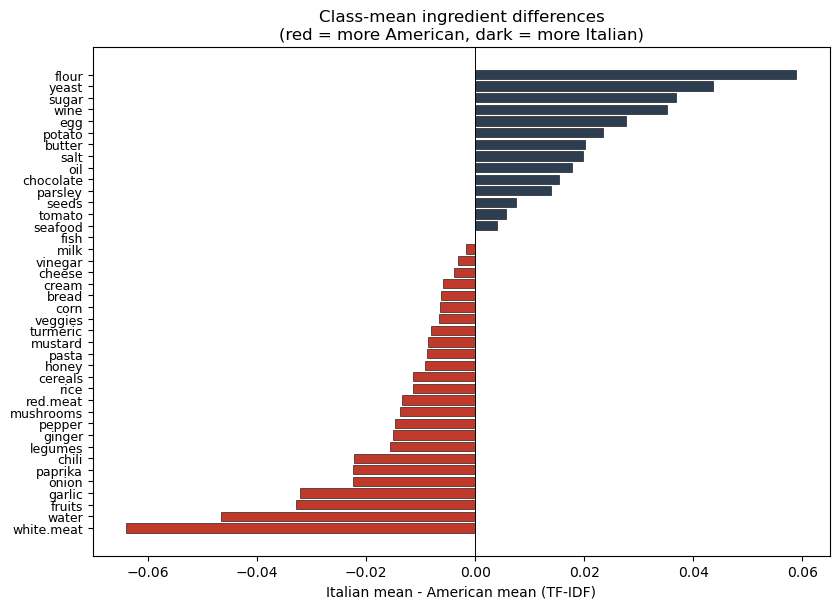

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 6.2))
colors = ["#c0392b" if v < 0 else "#2c3e50" for v in diff.values]
ax.barh(range(len(diff)), diff.values, color=colors, edgecolor="black", linewidth=0.4)
ax.set_yticks(range(len(diff)))
ax.set_yticklabels(diff.index, fontsize=9)
ax.axvline(0, color="black", linewidth=0.7)
ax.set_xlabel("Italian mean - American mean (TF-IDF)")
ax.set_title("Class-mean ingredient differences\n(red = more American, dark = more Italian)")
plt.tight_layout()
plt.savefig("fig1a_ingredient_diff.png", dpi=160)
plt.show()

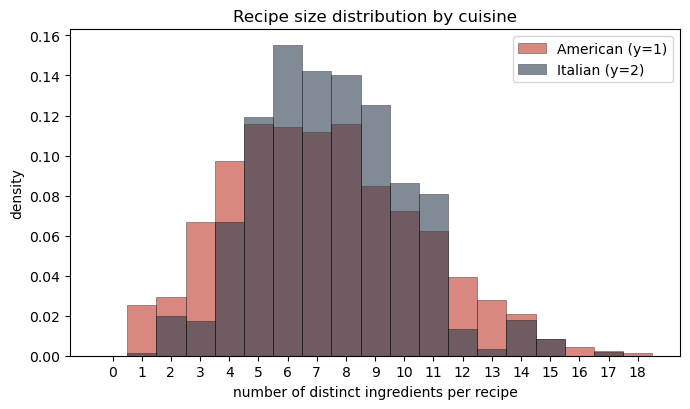

In [13]:
n_per_row = (train[feat] > 0).sum(axis=1)
fig, ax = plt.subplots(figsize=(7, 4.2))
bins = np.arange(0, n_per_row.max() + 2) - 0.5
ax.hist(n_per_row[train.y == 1], bins=bins, alpha=0.6, label="American (y=1)",
        color="#c0392b", edgecolor="black", linewidth=0.4, density=True)
ax.hist(n_per_row[train.y == 2], bins=bins, alpha=0.6, label="Italian (y=2)",
        color="#2c3e50", edgecolor="black", linewidth=0.4, density=True)
ax.set_xlabel("number of distinct ingredients per recipe")
ax.set_xticks(np.arange(0, n_per_row.max() + 1, 1))
ax.set_ylabel("density")
ax.set_title("Recipe size distribution by cuisine")
ax.legend()
plt.tight_layout()
plt.savefig("fig1b_recipe_size.png", dpi=160)
plt.show()

### Row-aggregate features

In [14]:
X_tr = train[feat]
total_mass = X_tr.sum(axis=1)
n_ing = (X_tr > 0).sum(axis=1)
mean_intensity = total_mass / n_ing
df = pd.DataFrame({"total_mass": total_mass, "mean_intensity": mean_intensity,
                    "n_ingredients": n_ing, "y": train.y})
cols = ["total_mass", "mean_intensity", "n_ingredients"]
means = df.groupby("y")[cols].mean()
stds = df.groupby("y")[cols].std()
pd.concat({"mean": means, "std": stds}, axis=1)

mean                                     std                             
  total_mass mean_intensity n_ingredients total_mass mean_intensity n_ingredients
y                                                                                
1   1.625558       0.309011      7.202670   0.265837       0.307634      3.242694
2   1.548142       0.235500      7.499356   0.173113       0.108537      2.566711